# Balanced Binary Classification (Normal vs. Abnormal) Pipeline
This notebook has been securely refactored to focus 100% on a completely unbiased, 50/50 binary classification of CTG signals.


In [1]:
%matplotlib inline
import os, glob, random, shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Dense, Dropout, BatchNormalization,
    GlobalAveragePooling2D, GlobalAveragePooling1D,
    LSTM, Bidirectional, Concatenate,
    MultiHeadAttention, LayerNormalization
)
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.optimizers import Adam, RMSprop, SGD
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, Callback
from tensorflow.keras.regularizers import l2

# Reproducibility
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f"Environments ready. Seed: {SEED}")


2026-04-01 18:25:17.576753: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775067917.770479      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775067917.825492      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775067918.263671      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775067918.263721      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775067918.263724      55 computation_placer.cc:177] computation placer alr

Environments ready. Seed: 42


In [2]:
# --- Paths & Constants ---


BASE_DIR  = '/kaggle/input/datasets/annn51/final-resnet50/data_aug'
MODEL_DIR = '/kaggle/working/models'
PLOTS_DIR = '/kaggle/working/plots/binary'

for d in [MODEL_DIR, PLOTS_DIR]:
    os.makedirs(d, exist_ok=True)

SEQ_LEN     = 120
IMG_SIZE    = (224, 224)
BATCH_SIZE  = 32

# Strictly defined for binary
LABEL_NAMES = ['Normal', 'Abnormal']
COLORS = ['#2ecc71', '#e74c3c']

In [3]:
# --- Data Loading (3 Classes) ---
def load_balanced_data(base_path):
    print("Loading 3-class data samples...")
    X, y = [], []
    class_map = {'normal': 0, 'suspect': 1, 'pathologic': 2}

    for class_name, label_idx in class_map.items():
        class_dir = os.path.join(base_path, class_name)
        files = glob.glob(os.path.join(class_dir, '*.npy'))
        for f in files:
            X.append(np.load(f))
            y.append(label_idx)

    return np.array(X), np.array(y)

X_raw, y_raw = load_balanced_data(BASE_DIR)
print(f"Total Raw Data Loaded: {X_raw.shape}")


Loading 3-class data samples...
Total Raw Data Loaded: (43308, 120, 1)


## 1. Label Merging & Strict 3,600 Subsampling
We logically collapse `Suspect` and `Pathologic` into `Abnormal`, then slice precisely 3,600 datapoints across the board to ensure true 50/50 balance without algorithmic weighting.


In [4]:
# --- True Binary Conversion ---
N_SAMPLES = 5000

# y_raw 0=Normal, 1=Suspect, 2=Pathologic
y_binary_full = np.where(y_raw > 0, 1, 0)

normal_indices = np.where(y_binary_full == 0)[0]
abnormal_indices = np.where(y_binary_full == 1)[0]

np.random.shuffle(normal_indices)
np.random.shuffle(abnormal_indices)

normal_subset = normal_indices[:N_SAMPLES]
abnormal_subset = abnormal_indices[:N_SAMPLES]

final_indices = np.concatenate([normal_subset, abnormal_subset])
np.random.shuffle(final_indices)

X_bin = X_raw[final_indices]
y_bin = y_binary_full[final_indices]
counts = np.bincount(y_bin)

print(f"Extraction Complete. Total binary samples: {len(X_bin)}")
print(f"Class distribution: {dict(zip(LABEL_NAMES, counts))}")


Extraction Complete. Total binary samples: 10000
Class distribution: {'Normal': np.int64(5000), 'Abnormal': np.int64(5000)}


## 2. Advanced Binary EDA (Exploratory Data Analysis)


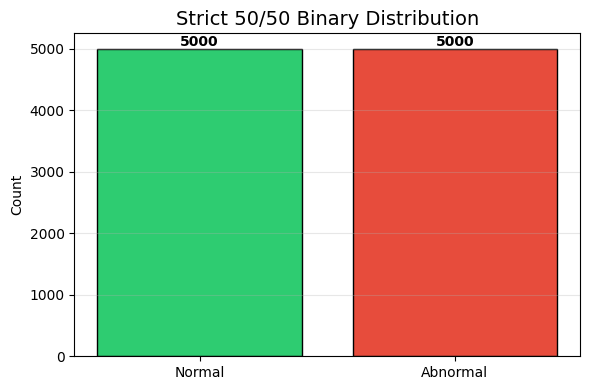

In [5]:
# 1. Class distribution
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(LABEL_NAMES, counts, color=COLORS, edgecolor='black')
for bar, c in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 50,
            str(c), ha='center', fontweight='bold')
ax.set_title('Strict 50/50 Binary Distribution', fontsize=14)
ax.set_ylabel('Count')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'eda_01_binary_dist.png'), dpi=150)
plt.show()


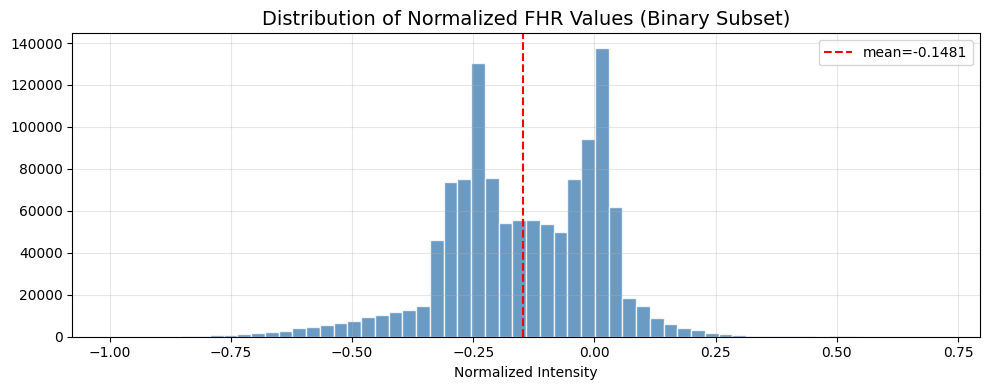

In [6]:
# 2. Overall signal value distribution
fhr_flat = X_bin.flatten()
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(fhr_flat, bins=60, color='steelblue', edgecolor='white', alpha=0.8)
ax.axvline(fhr_flat.mean(), color='red', linestyle='--', label=f'mean={fhr_flat.mean():.4f}')
ax.set_title('Distribution of Normalized FHR Values (Binary Subset)', fontsize=14)
ax.set_xlabel('Normalized Intensity')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'eda_02_signal_dist.png'), dpi=150)
plt.show()


/tmp/ipykernel_55/3267318961.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(box_data, labels=LABEL_NAMES, patch_artist=True,


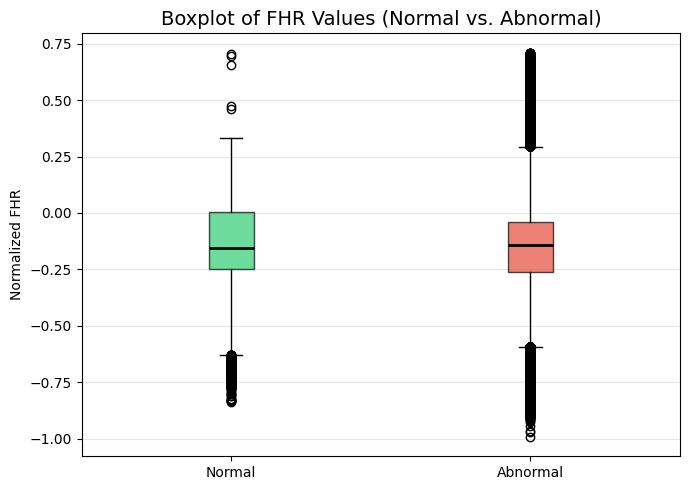

In [7]:
# 3. Per-class statistics Boxplot
box_data = [X_bin[y_bin == i].flatten() for i in range(2)]
fig, ax = plt.subplots(figsize=(7, 5))
bp = ax.boxplot(box_data, labels=LABEL_NAMES, patch_artist=True,
                medianprops=dict(color='black', linewidth=2))
for patch, color in zip(bp['boxes'], COLORS):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.set_title('Boxplot of FHR Values (Normal vs. Abnormal)', fontsize=14)
ax.set_ylabel('Normalized FHR')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'eda_03_boxplot.png'), dpi=150)
plt.show()


## 3. Data Splits & Dataset Generators


In [8]:
# 70 / 15 / 15 split
X_tr, X_tmp, y_tr, y_tmp = train_test_split(
    X_bin, y_bin, test_size=0.30, random_state=SEED, stratify=y_bin)
X_va, X_te, y_va, y_te = train_test_split(
    X_tmp, y_tmp, test_size=0.50, random_state=SEED, stratify=y_tmp)

print(f"Train: {len(y_tr)}")
print(f"Val:   {len(y_va)}")
print(f"Test:  {len(y_te)}")


Train: 7000
Val:   1500
Test:  1500


In [9]:
def sequence_to_plot(seq):
    img = np.ones((224, 224, 3), dtype=np.uint8) * 255
    pad = 8
    w = 224 - 2 * pad
    h = 224 - 2 * pad
    seq_min, seq_max = seq.min(), seq.max()
    if seq_max > seq_min:
        y_scaled = (seq - seq_min) / (seq_max - seq_min)
    else:
        y_scaled = np.zeros_like(seq) + 0.5
    y_coords = 224 - pad - (y_scaled * h).astype(np.int32)
    x_coords = np.linspace(pad, 224 - pad, len(seq)).astype(np.int32)
    pts = np.column_stack((x_coords, y_coords)).reshape((-1, 1, 2))
    cv2.polylines(img, [pts], isClosed=False, color=(255, 0, 0), thickness=2, lineType=cv2.LINE_AA)
    return (cv2.resize(img, IMG_SIZE) / 255.0).astype(np.float32)

def make_dataset(X_seq, y, shuffle=True):
    ds = tf.data.Dataset.from_tensor_slices((X_seq, y))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(X_seq), reshuffle_each_iteration=True)
    
    def process_element(x_tensor, y_tensor):
        def _process(x):
            seq = x.reshape(SEQ_LEN, 1).astype(np.float32)
            img = sequence_to_plot(x.flatten())
            return img, seq
        img, seq = tf.numpy_function(_process, [x_tensor], [tf.float32, tf.float32])
        img.set_shape((224, 224, 3))
        seq.set_shape((SEQ_LEN, 1))
        expanded_y = tf.cast(tf.expand_dims(y_tensor, -1), tf.float32)
        return (img, seq), expanded_y

    # ✅ FIX: use deterministic=True so output order is preserved
    ds = ds.map(process_element,
                num_parallel_calls=tf.data.AUTOTUNE,
                deterministic=True)          # ← add this
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = make_dataset(X_tr, y_tr, shuffle=True)
val_ds   = make_dataset(X_va, y_va, shuffle=False)
test_ds  = make_dataset(X_te, y_te, shuffle=False)


I0000 00:00:1775068190.529678      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


## 4. Binary Architecture (Anti-Overfitting Restraints Applied)
Built precisely on the ResNet50 + Bidirectional LSTM frame, incorporating parameter elimination `[128, 64]` and severe L2 Ridge Regularization `kernel_regularizer=l2(1e-4)` to prevent dataset memorization blockades.


In [10]:
cfg_bin = {
    'name': 'binary_3600_advanced',
    'lstm_units': 128,
    'lstm_layers': 1,
    'attn_num_heads': 4,
    'attn_key_dim': 32,
    'cnn_dense': 256,
    'head_dense': [128, 64],
    'dropout': 0.40,
    'optimizer': 'rmsprop',
    'lr_phase1': 1e-3,
    'lr_phase2': 1e-5,
    'unfreeze_layers': 50,
    'epochs_p1': 20,
    'epochs_p2': 30,
}

def build_model(cfg):
    # CNN branch
    img_inp = Input(shape=(224, 224, 3), name='image_input')
    base    = ResNet50(weights='imagenet', include_top=False, input_tensor=img_inp)
    base.trainable = False

    cnn = GlobalAveragePooling2D()(base.output)
    cnn = BatchNormalization()(cnn)
    cnn = Dense(cfg['cnn_dense'], activation='relu', kernel_regularizer=l2(1e-4))(cnn)
    cnn = Dropout(cfg['dropout'])(cnn)

    # LSTM + Attention branch
    seq_inp = Input(shape=(SEQ_LEN, 1), name='seq_input')
    x = seq_inp
    for _ in range(cfg['lstm_layers']):
        x = Bidirectional(LSTM(cfg['lstm_units'], return_sequences=True))(x)
        x = BatchNormalization()(x)
        x = Dropout(cfg['dropout'])(x)

    attn = MultiHeadAttention(num_heads=cfg['attn_num_heads'], key_dim=cfg['attn_key_dim'])(x, x)
    attn = LayerNormalization()(attn)
    lstm_attn = GlobalAveragePooling1D()(attn)
    lstm_attn = Dense(cfg['lstm_units'], activation='relu', kernel_regularizer=l2(1e-4))(lstm_attn)

    # Merged classification head
    m = Concatenate()([cnn, lstm_attn])
    for units in cfg['head_dense']:
        m = Dense(units, activation='relu', kernel_regularizer=l2(1e-4))(m)
        m = BatchNormalization()(m)
        m = Dropout(cfg['dropout'])(m)
    
    # Sigmoid output for strictly binary target
    out = Dense(1, activation='sigmoid', kernel_regularizer=l2(1e-4))(m)

    return Model(inputs=[img_inp, seq_inp], outputs=out), base

model, base = build_model(cfg_bin)
model.summary()


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ image_input[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 24,478,081 (93.38 MB)

 Trainable params: 885,377 (3.38 MB)

 Non-trainable params: 23,592,704 (90.00 MB)

In [11]:
class BinaryEpochMetrics(Callback):
    def __init__(self, val_ds, cfg_name):
        super().__init__()
        self.val_ds   = val_ds
        self.cfg_name = cfg_name

    def on_epoch_end(self, epoch, logs=None):
        y_true_all, y_pred_all = [], []

        for (img_batch, seq_batch), label_batch in self.val_ds:
            probs = self.model([img_batch, seq_batch], training=False)
            probs = probs.numpy().flatten()
            preds = (probs >= 0.5).astype(int)
            
            labels = label_batch.numpy().flatten().astype(int)
            
            y_pred_all.extend(preds)
            y_true_all.extend(labels)

        print(f"\n=== [{self.cfg_name}] Epoch {epoch+1} — Validation Metrics ===")
        print(classification_report(y_true_all, y_pred_all, target_names=LABEL_NAMES))

## 5. Active Training & Final Evaluation


In [12]:
def get_optimizer(name, lr):
    name = name.lower()
    if name == 'adam':    return Adam(lr)
    if name == 'rmsprop': return RMSprop(lr)
    if name == 'sgd':     return SGD(lr, momentum=0.9)
    raise ValueError(f"Unknown optimizer: {name}")

cbs = [
    EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-7, verbose=1),
    BinaryEpochMetrics(val_ds, cfg_bin['name']),  # ← no y_va here
]

# --- Phase 1: Frozen Backbone ---
print(f"\nPhase 1: backbone frozen | lr={cfg_bin['lr_phase1']} | opt={cfg_bin['optimizer']}")
model.compile(optimizer=get_optimizer(cfg_bin['optimizer'], cfg_bin['lr_phase1']),
              loss='binary_crossentropy', metrics=['accuracy'])
h1 = model.fit(train_ds, validation_data=val_ds,
               epochs=cfg_bin['epochs_p1'], callbacks=cbs, verbose=1)

# --- Phase 2: Unfrozen Top Layers ---
print(f"\nPhase 2: unfreeze top {cfg_bin['unfreeze_layers']} layers | lr={cfg_bin['lr_phase2']}")
base.trainable = True
for layer in base.layers[:-cfg_bin['unfreeze_layers']]:
    layer.trainable = False
model.compile(optimizer=get_optimizer(cfg_bin['optimizer'], cfg_bin['lr_phase2']),
              loss='binary_crossentropy', metrics=['accuracy'])
h2 = model.fit(train_ds, validation_data=val_ds,
               epochs=cfg_bin['epochs_p2'], callbacks=cbs, verbose=1)

val_acc = max(h1.history['val_accuracy'] + h2.history['val_accuracy'])
mp = os.path.join(MODEL_DIR, f"{cfg_bin['name']}_final.keras")
model.save(mp)
print(f"\nBinary Model saved -> {mp}")



Phase 1: backbone frozen | lr=0.001 | opt=rmsprop
Epoch 1/20


I0000 00:00:1775068205.634547     163 cuda_dnn.cc:529] Loaded cuDNN version 91002


219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - accuracy: 0.8969 - loss: 0.3985
=== [binary_3600_advanced] Epoch 1 — Validation Metrics ===
              precision    recall  f1-score   support

      Normal       1.00      0.85      0.92       750
    Abnormal       0.87      1.00      0.93       750

    accuracy                           0.93      1500
   macro avg       0.93      0.93      0.92      1500
weighted avg       0.93      0.93      0.92      1500

219/219 ━━━━━━━━━━━━━━━━━━━━ 55s 191ms/step - accuracy: 0.8970 - loss: 0.3983 - val_accuracy: 0.9253 - val_loss: 0.4057 - learning_rate: 0.0010
Epoch 2/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - accuracy: 0.9386 - loss: 0.2974
=== [binary_3600_advanced] Epoch 2 — Validation Metrics ===
              precision    recall  f1-score   support

      Normal       1.00      0.89      0.94       750
    Abnormal       0.90      1.00      0.95       750

    accuracy                           0.94      1500
   macro avg       0.95     

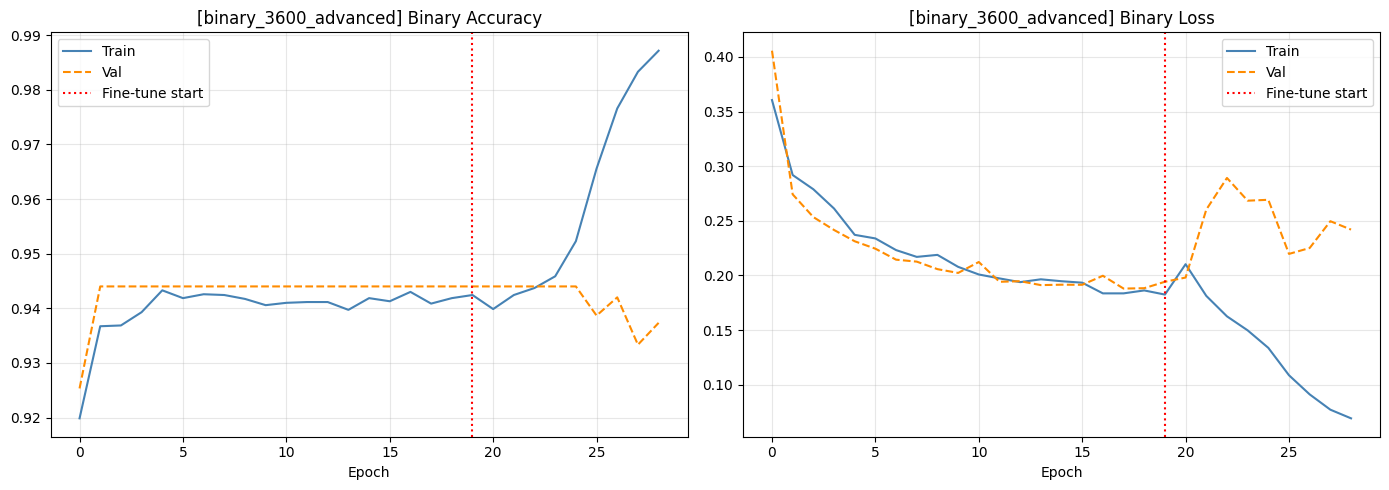

In [13]:
# Learning Curves
acc     = h1.history['accuracy']     + h2.history['accuracy']
val_acc = h1.history['val_accuracy'] + h2.history['val_accuracy']
loss    = h1.history['loss']         + h2.history['loss']
val_los = h1.history['val_loss']     + h2.history['val_loss']
p1_end  = len(h1.history['accuracy']) - 1

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
for ax, tr, va, title in [(ax1, acc, val_acc, 'Accuracy'),
                           (ax2, loss, val_los, 'Loss')]:
    ax.plot(tr, label='Train', color='steelblue')
    ax.plot(va, label='Val', linestyle='--', color='darkorange')
    ax.axvline(p1_end, color='red', linestyle=':', label='Fine-tune start')
    ax.set_title(f"[{cfg_bin['name']}] Binary {title}", fontsize=12)
    ax.set_xlabel('Epoch')
    ax.legend()
    ax.grid(alpha=0.3)
plt.tight_layout()
lc_path = os.path.join(PLOTS_DIR, 'lc_binary.png')
plt.savefig(lc_path, dpi=150)
plt.show()



🔥 FINAL TEST ACCURACY: 94.40% 🔥

=== BINARY MODEL FINAL TEST EVALUATION ===
              precision    recall  f1-score   support

      Normal       1.00      0.89      0.94       750
    Abnormal       0.90      1.00      0.95       750

    accuracy                           0.94      1500
   macro avg       0.95      0.94      0.94      1500
weighted avg       0.95      0.94      0.94      1500



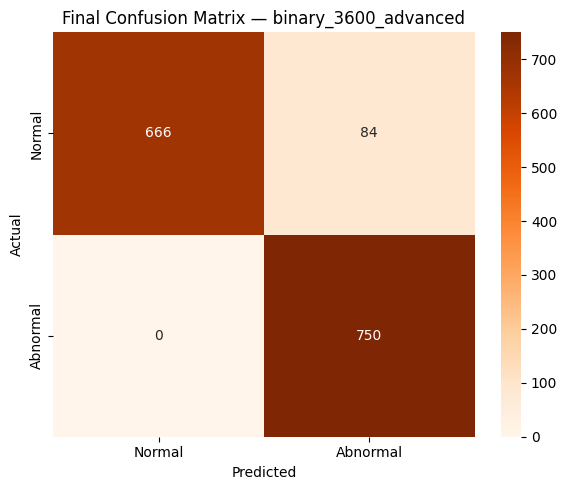

In [14]:
# Final Explicit Evaluation Block
loss_eval, test_acc = model.evaluate(test_ds, verbose=0)
print(f"\n{'='*40}\n🔥 FINAL TEST ACCURACY: {test_acc*100:.2f}% 🔥\n{'='*40}")

probs_te = model.predict(test_ds, verbose=0)
y_pred_te = (probs_te >= 0.5).astype(int).flatten()

print('\n=== BINARY MODEL FINAL TEST EVALUATION ===')
print(classification_report(y_te, y_pred_te, target_names=LABEL_NAMES))

cm = confusion_matrix(y_te, y_pred_te)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES, ax=ax)
ax.set_title(f"Final Confusion Matrix — {cfg_bin['name']}")
ax.set_ylabel('Actual')
ax.set_xlabel('Predicted')
plt.tight_layout()
bin_fp = os.path.join(PLOTS_DIR, 'final_test_cm_binary_pristine.png')
plt.savefig(bin_fp, dpi=150)
plt.show()


In [ ]:
import shutil
shutil.make_archive('/kaggle/working/files', 'zip', '/kaggle/working')

In [ ]:
import os
os.listdir('/kaggle/working')